# Metropolis: Tuning

running simulation: 100%|██████████| 2000/2000 [00:00<00:00, 5483.08it/s]


# Question 1: Change of acceptance rate with increasing L, constant width

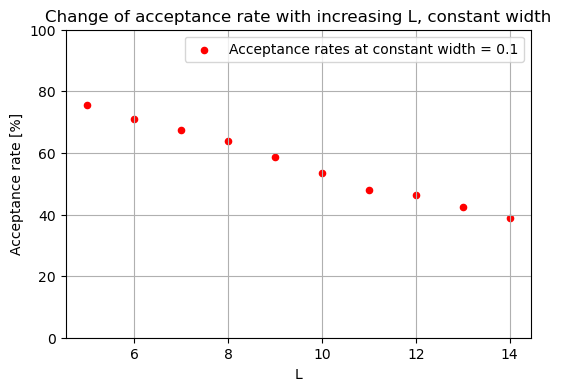

# Question 2: Constant acceptance rate by increasing L and decreasing width

Question 3: The widths are chosen such that the acceptance rate lies between 70 - 80%.

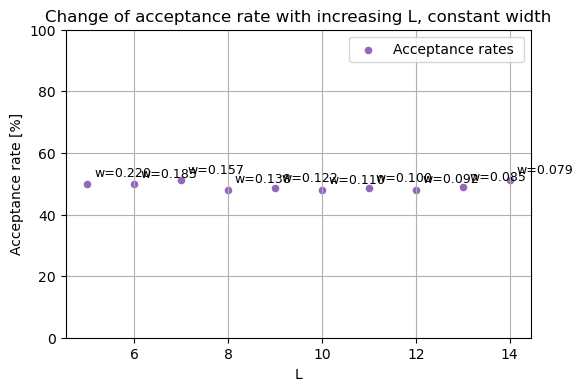

In [4]:
from IPython.display import display, Markdown
import numpy as np
import matplotlib.pyplot as plt
from algorithms.metropolis import run_metropolis

L_vals = list(range(5, 15))
m2 = -0.5
lam = 5.0
rng = np.random.default_rng(seed=42)

acceptance_rates = []
constant_acceptance_rates = []
adapted_widths = []
for L in L_vals:
    phi_field = rng.random(size=(L, L))
    width = 0.1
    adapted_width = 1.1/L
    adapted_widths.append(adapted_width)
    acceptance = run_metropolis(phi_field, m2, lam, width, 2000, rng)
    const_acceptance = run_metropolis(phi_field, m2, lam, adapted_width, 2000, rng)
    acceptance_rates.append(np.mean(acceptance)*100)
    constant_acceptance_rates.append(np.mean(const_acceptance)*100)

display(Markdown("# Question 1: Change of acceptance rate with increasing L, constant width"))
plt.figure(figsize = (6, 4))
plt.scatter(L_vals, acceptance_rates, c= "r", s = 20, label = f"Acceptance rates at constant width = {width}")
plt.title("Change of acceptance rate with increasing L, constant width")
plt.xlabel("L")
plt.ylabel("Acceptance rate [%]")
plt.legend()
plt.ylim(0, 100)
plt.grid(True)
plt.show()

display(Markdown("# Question 2: Constant acceptance rate by increasing L and decreasing width"))
display(Markdown("Question 3: The widths are chosen such that the acceptance rate lies between 70 - 80%."))
plt.figure(figsize = (6, 4))
plt.scatter(L_vals, constant_acceptance_rates, c= 'tab:purple', s = 20, label = f"Acceptance rates ")
plt.title("Change of acceptance rate with increasing L, constant width")
plt.xlabel("L")
plt.ylabel("Acceptance rate [%]")
plt.legend()
plt.ylim(0, 100)
plt.grid(True)
for L, acc, w in zip(L_vals, constant_acceptance_rates, adapted_widths):
    plt.annotate(f"w={w:.3f}", (L, acc), textcoords="offset points", xytext=(5, 5), ha='left', fontsize=9, color='black')

plt.show()

# HMC: Tuning

running simulation:   0%|          | 0/2000 [00:00<?, ?it/s]

running simulation: 100%|██████████| 2000/2000 [00:45<00:00, 43.78it/s]


# Question 1: Change of acceptance rate with increasing L, constant width

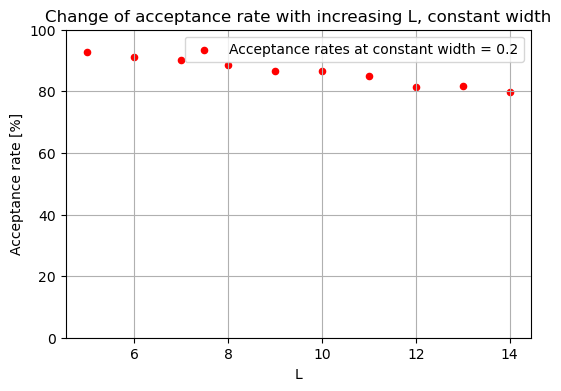

# Question 2: Constant acceptance rate by increasing L and decreasing width

Question 3: The widths are chosen such that the acceptance rate lies between 70 - 80%.

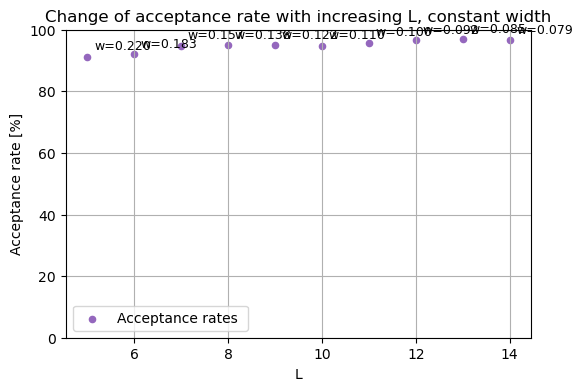

In [9]:
from IPython.display import display, Markdown
import numpy as np
import matplotlib.pyplot as plt
from algorithms.hmc import run_hmc

L_vals = list(range(5, 15))
m2 = -0.5
lam = 5.0
rng = np.random.default_rng(seed=42)

acceptance_rates = []
constant_acceptance_rates = []
adapted_widths = []
for L in L_vals:
    phi_field = rng.random(size=(L, L))
    width = 0.2
    adapted_width = 1.1/L
    adapted_widths.append(adapted_width)
    acceptance = run_hmc(phi_field, m2, lam, width, 2000, rng)
    const_acceptance = run_hmc(phi_field, m2, lam, adapted_width, 2000, rng)
    acceptance_rates.append(np.mean(acceptance)*100)
    constant_acceptance_rates.append(np.mean(const_acceptance)*100)

display(Markdown("# Question 1: Change of acceptance rate with increasing L, constant width"))
plt.figure(figsize = (6, 4))
plt.scatter(L_vals, acceptance_rates, c= "r", s = 20, label = f"Acceptance rates at constant width = {width}")
plt.title("Change of acceptance rate with increasing L, constant width")
plt.xlabel("L")
plt.ylabel("Acceptance rate [%]")
plt.legend()
plt.ylim(0, 100)
plt.grid(True)
plt.show()

display(Markdown("# Question 2: Constant acceptance rate by increasing L and decreasing width"))
display(Markdown("Question 3: The widths are chosen such that the acceptance rate lies between 70 - 80%."))
plt.figure(figsize = (6, 4))
plt.scatter(L_vals, constant_acceptance_rates, c= 'tab:purple', s = 20, label = f"Acceptance rates ")
plt.title("Change of acceptance rate with increasing L, constant width")
plt.xlabel("L")
plt.ylabel("Acceptance rate [%]")
plt.legend()
plt.ylim(0, 100)
plt.grid(True)
for L, acc, w in zip(L_vals, constant_acceptance_rates, adapted_widths):
    plt.annotate(f"w={w:.3f}", (L, acc), textcoords="offset points", xytext=(5, 5), ha='left', fontsize=9, color='black')

plt.show()

In [3]:
import numpy as np
import time
from tqdm import tqdm
from physics.observables import sample_observable
from algorithms import integrators

L_vals = list(range(4, 12))  

num_samples = 166320  # highly composite number
rng = np.random.default_rng(seed=42)

algorithms = {
    "Metropolis": {"algorithm": "Metropolis"},
    "HMC_leapfrog": {"algorithm": "HMC", "integrator": integrators.leapfrog},
    "HMC_omelyan2": {"algorithm": "HMC", "integrator": integrators.omelyan2}
}

# Define two  phases
phases = {
    "broken": {"m2": -0.5, "lam": 5.0},
    "symmetric": {"m2": +0.5, "lam": 5.0}
}

for phase_name, params in phases.items():
    m2 = params["m2"]
    lam = params["lam"]

    print(f"\nRunning {phase_name} phase (m2={m2}, lambda={lam})")

    for L in tqdm(L_vals, desc=f"{phase_name} phase: lattice sizes"):
        initial_phi = rng.random(size=(L, L))
        width_met = 0.5 / L

        data_dict = {}
        runtimes = {}

        for alg_name, alg_opts in algorithms.items():
            kwargs = alg_opts.copy()
            width = width_met

            t0 = time.perf_counter()
            measurements, accepted = sample_observable(
                initial_phi=initial_phi,
                num_samples=num_samples,
                mass2=m2,
                lamb=lam,
                width=width,
                rng=rng,
                observable=None,
                **kwargs
            )
            t1 = time.perf_counter()

            data_dict[f"{alg_name}_L{L}"] = measurements.astype(np.float32)
            runtimes[f"{alg_name}_L{L}"] = t1 - t0

        meas_filename = (
            f"observable_measurements_{phase_name}_"
            f"m2{m2}_lam{lam}_L{L}_all_algs.npz"
        )
        time_filename = (
            f"observable_runtimes_{phase_name}_"
            f"m2{m2}_lam{lam}_L{L}_all_algs.npz"
        )

        np.savez(meas_filename, **data_dict)
        np.savez(time_filename, **runtimes)

print("Measurements and runtimes saved for broken and symmetric phases.")



Running broken phase (m2=-0.5, lambda=5.0)


broken phase: lattice sizes:   0%|          | 0/8 [00:00<?, ?it/s]

Sampling (Metropolis):   0%|          | 0/166320 [00:00<?, ?it/s]

Sampling (HMC):   0%|          | 0/166320 [00:00<?, ?it/s]

Sampling (HMC):   0%|          | 0/166320 [00:00<?, ?it/s]

...

Sampling (Metropolis):   0%|          | 0/166320 [00:00<?, ?it/s]

Sampling (HMC):   0%|          | 0/166320 [00:00<?, ?it/s]

Sampling (HMC):   0%|          | 0/166320 [00:00<?, ?it/s]

symmetric phase: lattice sizes: 100%|██████████| 8/8 [14:37:16<00:00, 6579.55s/it]  

Measurements and runtimes saved for broken and symmetric phases.


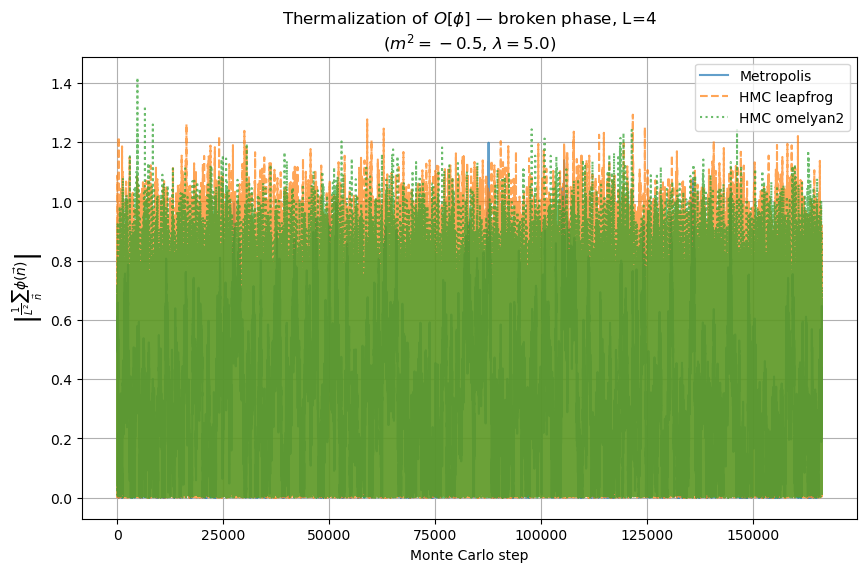

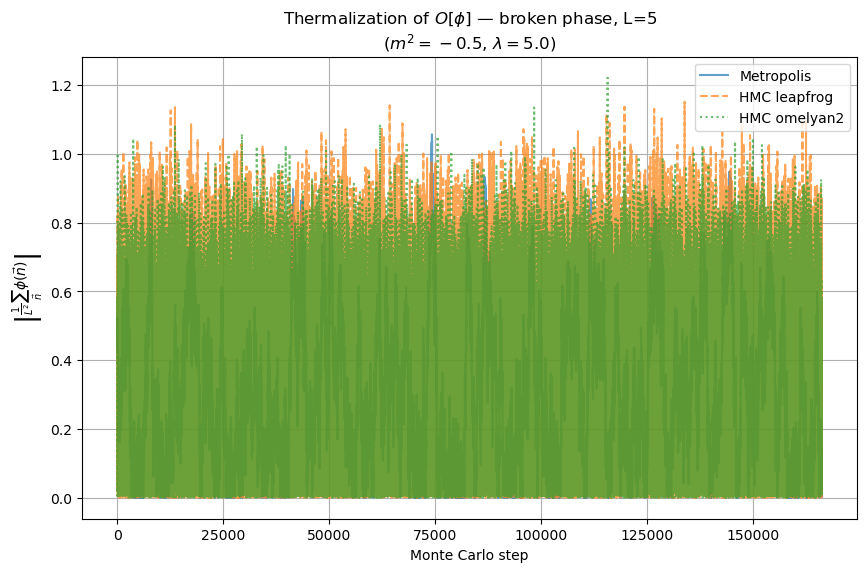

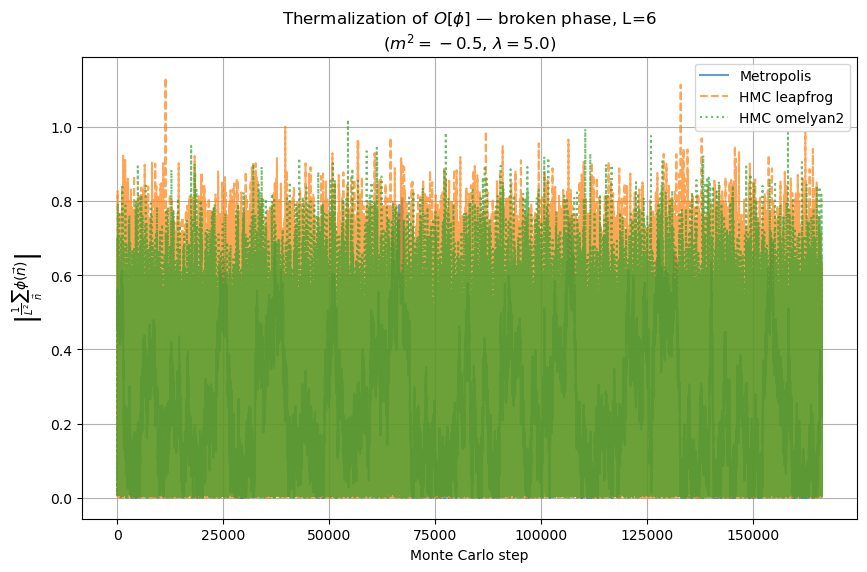

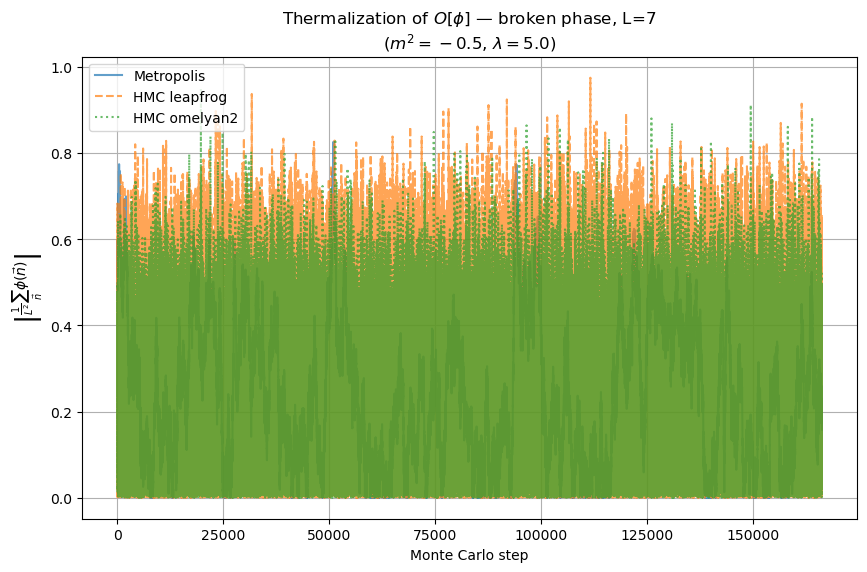

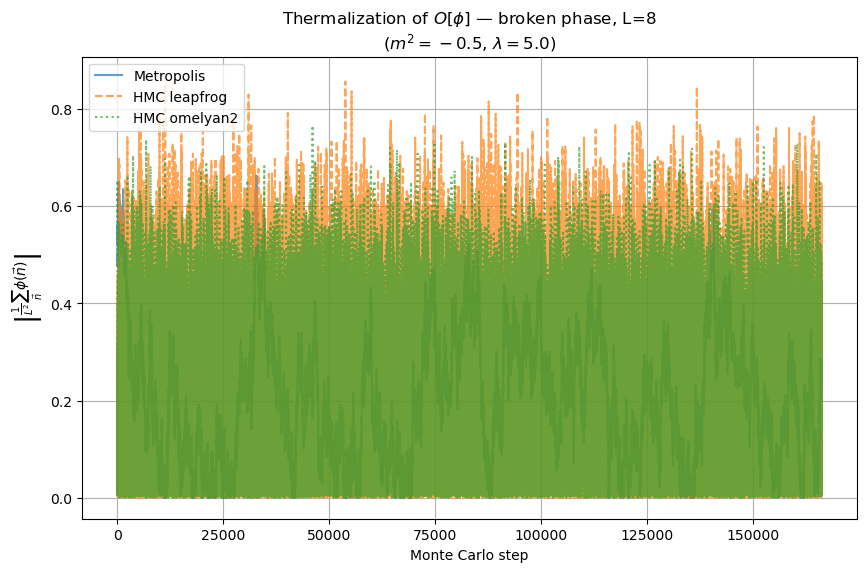

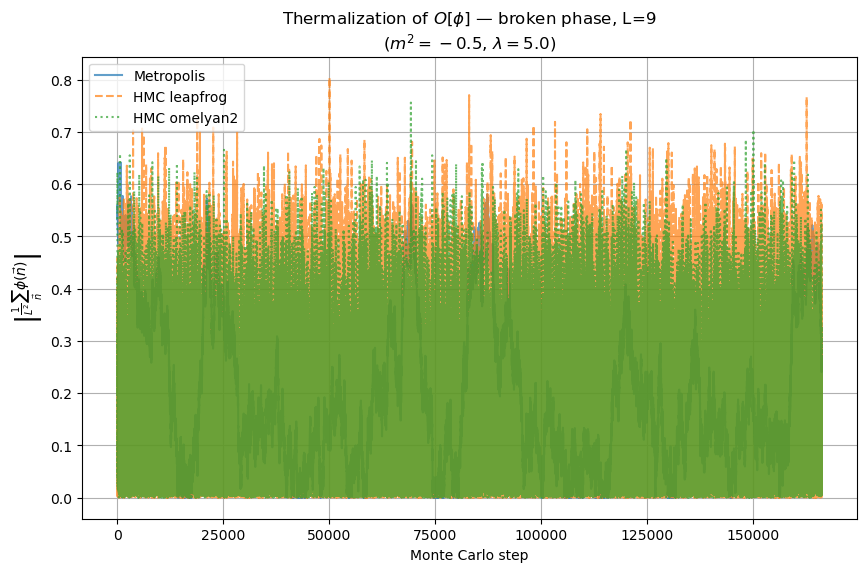

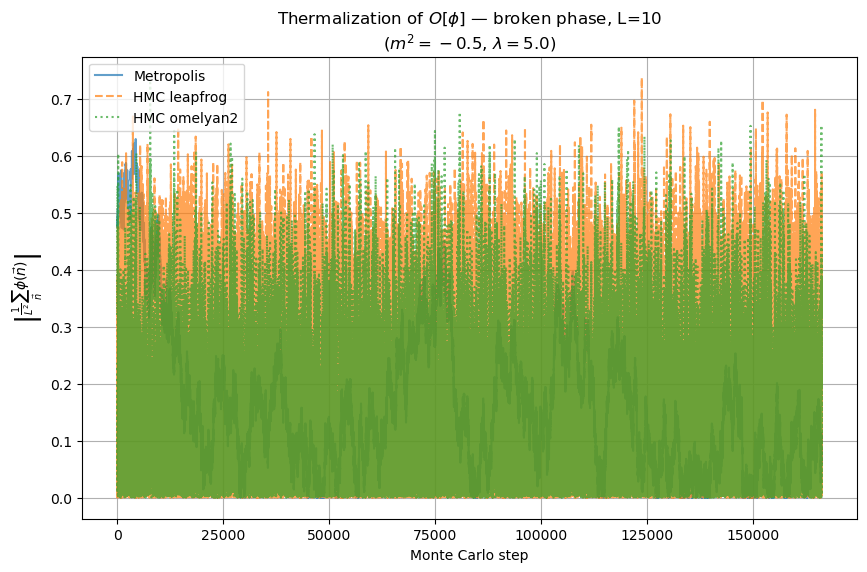

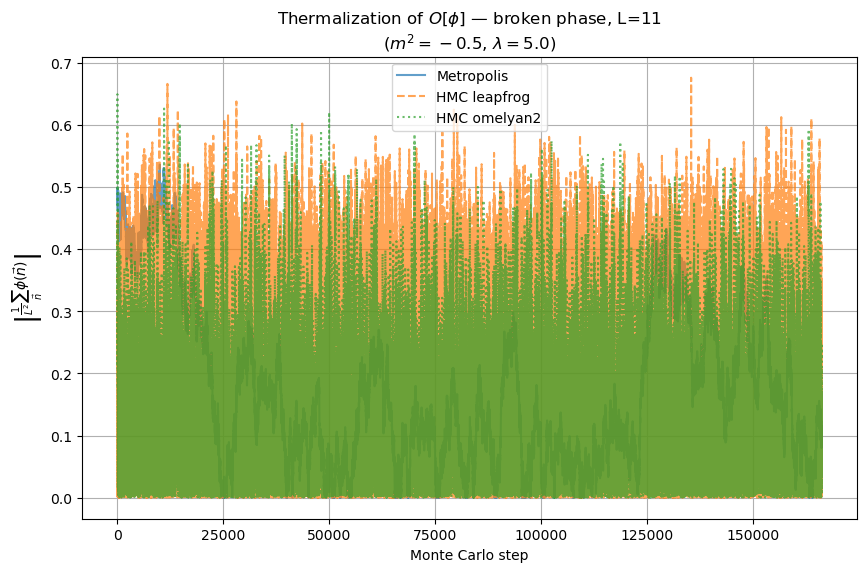

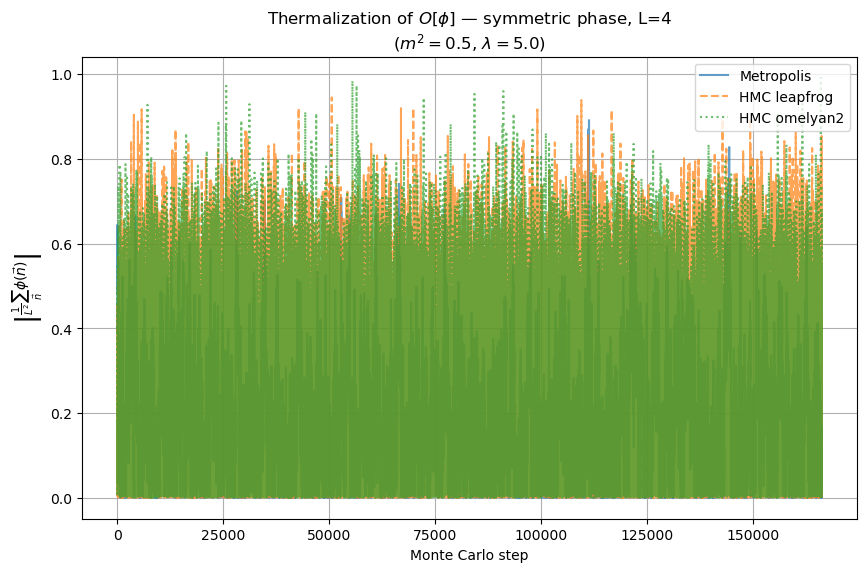

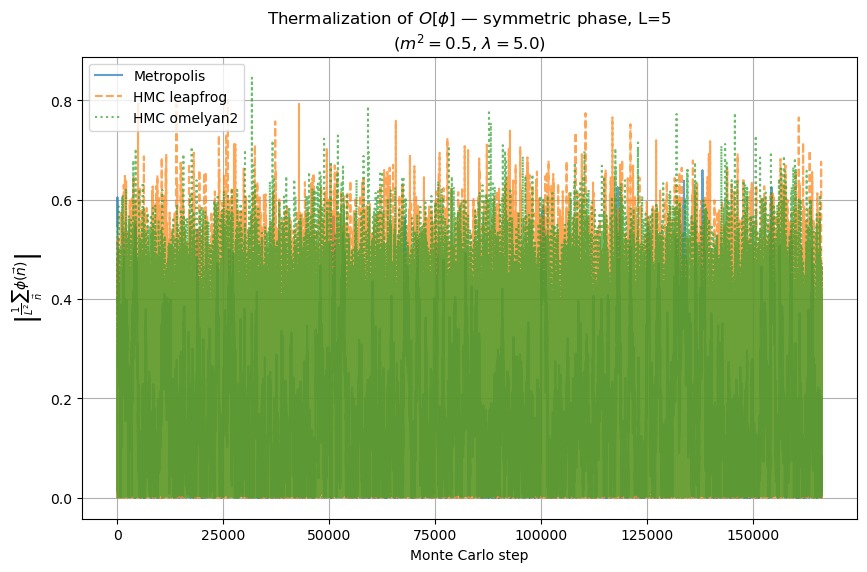

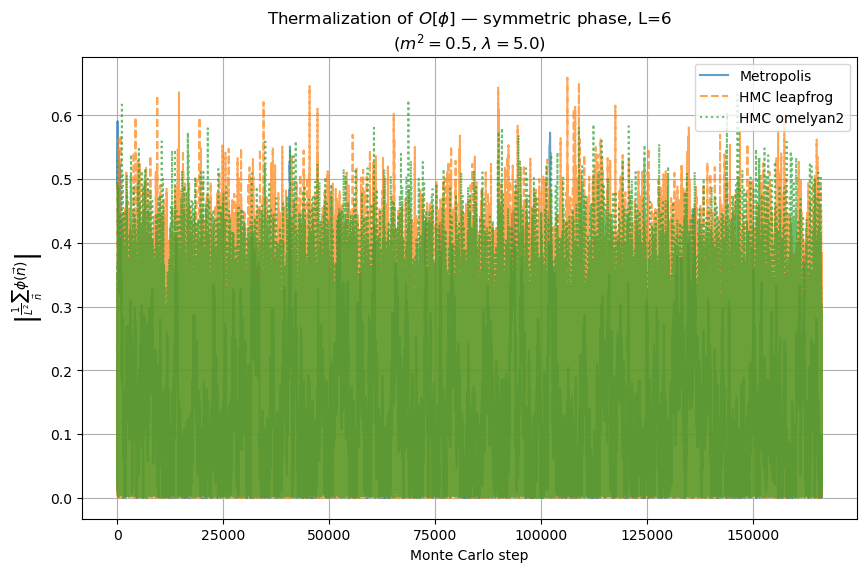

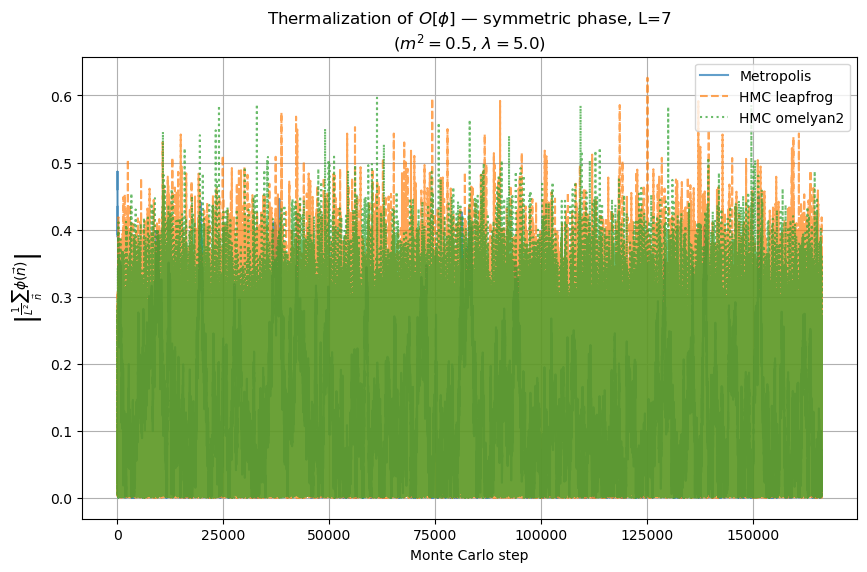

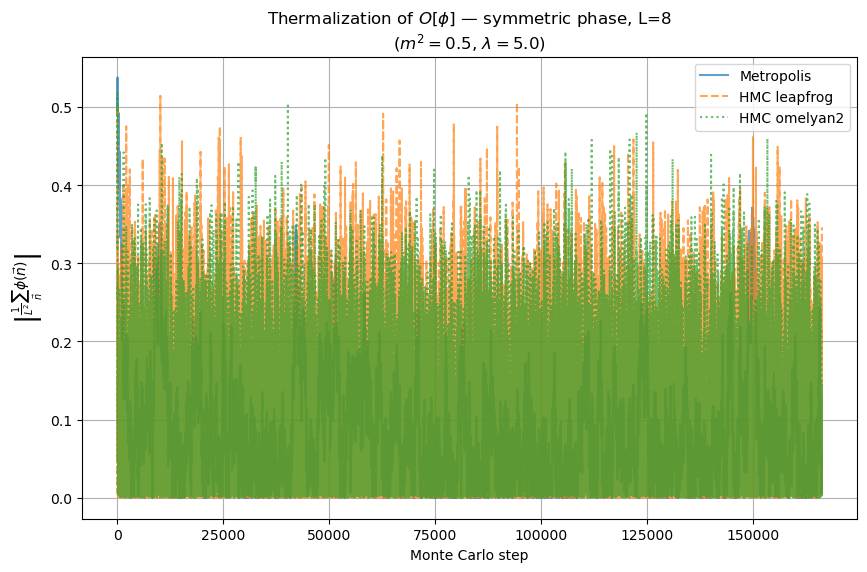

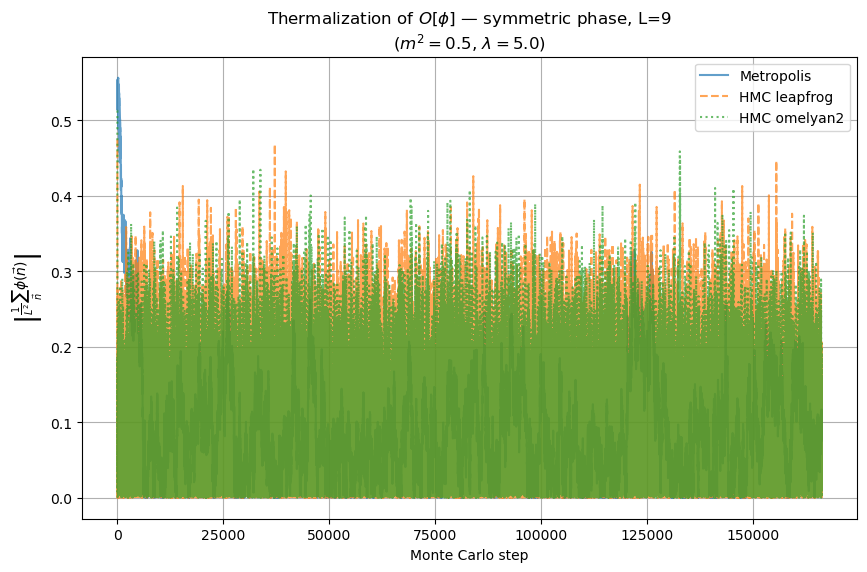

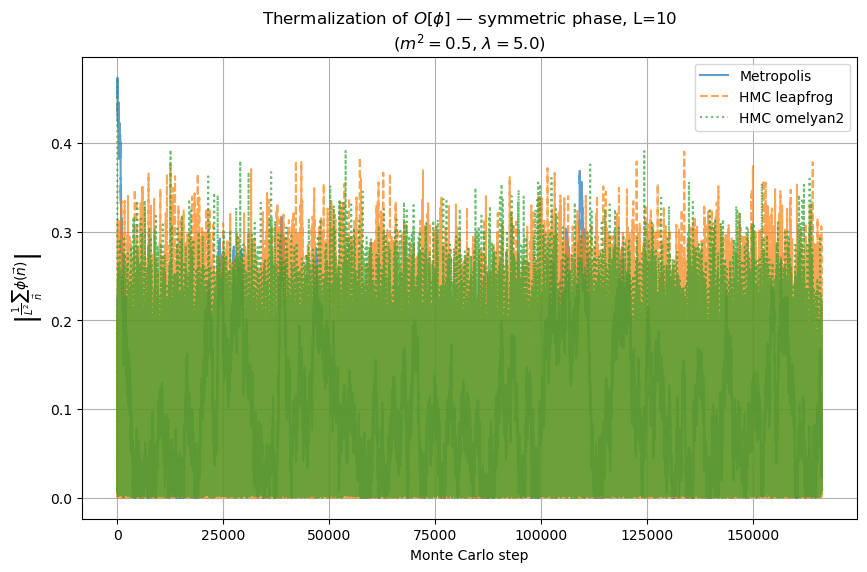

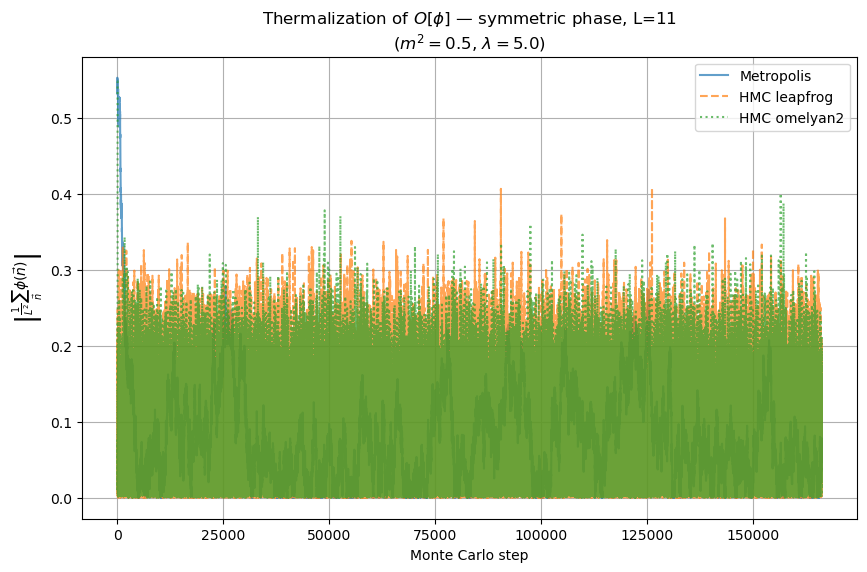

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from stats.analysis import apply_binning, integrated_autocorr_time, autocorrelation

L_vals = list(range(4, 12))

phases = {
    "broken": {"m2": -0.5, "lam": 5.0},
    "symmetric": {"m2": +0.5, "lam": 5.0},
}

algorithms = ["Metropolis", "HMC_leapfrog", "HMC_omelyan2"]

for phase_name, params in phases.items():
    m2 = params["m2"]
    lam = params["lam"]

    for L in L_vals:
        filename = (
            f"observable_measurements_{phase_name}_"
            f"m2{m2}_lam{lam}_L{L}_all_algs.npz"
        )
        data = np.load(filename)

        plt.figure(figsize=(10, 6))

        plt.plot(
            data[f"Metropolis_L{L}"],
            label="Metropolis",
            alpha=0.7,
        )

        plt.plot(
            data[f"HMC_leapfrog_L{L}"],
            linestyle="--",
            label="HMC leapfrog",
            alpha=0.7,
        )

        plt.plot(
            data[f"HMC_omelyan2_L{L}"],
            linestyle=":",
            label="HMC omelyan2",
            alpha=0.7,
        )

        plt.title(
            f"Thermalization of $O[\\phi]$ — {phase_name} phase, L={L}\n"
            rf"($m^2={m2}$, $\lambda={lam}$)"
        )
        plt.xlabel("Monte Carlo step")
        plt.ylabel(r"$\left| \frac{1}{L^2} \sum_{\vec n} \phi(\vec n) \right|$")
        plt.legend()
        plt.grid(True)
        plt.show()


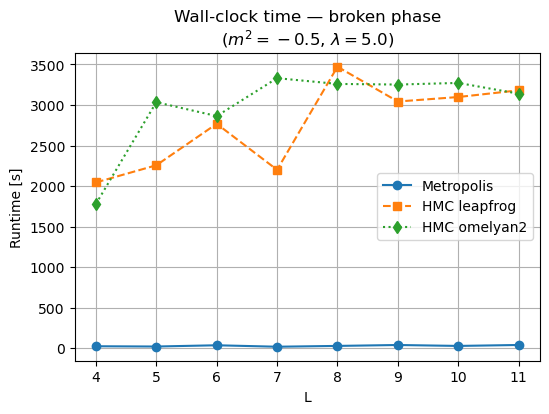

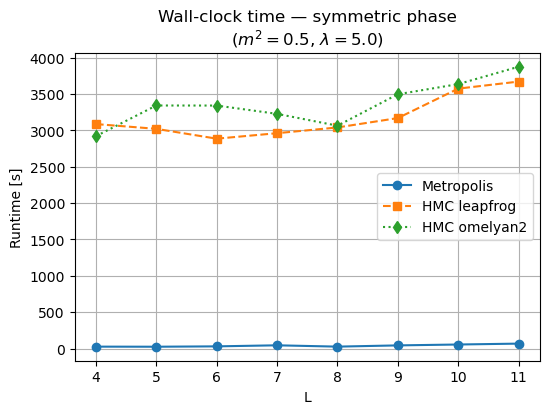

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from stats.analysis import apply_binning, integrated_autocorr_time, autocorrelation

L_vals = list(range(4, 12))

phases = {
    "broken": {"m2": -0.5, "lam": 5.0},
    "symmetric": {"m2": +0.5, "lam": 5.0},
}

algorithms = ["Metropolis", "HMC_leapfrog", "HMC_omelyan2"]

for phase_name, params in phases.items():
    m2 = params["m2"]
    lam = params["lam"]

    runtimes = [
        np.load(
            f"observable_runtimes_{phase_name}_"
            f"m2{m2}_lam{lam}_L{L}_all_algs.npz"
        )
        for L in L_vals
    ]

    t_met = [r[f"Metropolis_L{L}"] for r, L in zip(runtimes, L_vals)]
    t_hmc_lf = [r[f"HMC_leapfrog_L{L}"] for r, L in zip(runtimes, L_vals)]
    t_hmc_om = [r[f"HMC_omelyan2_L{L}"] for r, L in zip(runtimes, L_vals)]

    plt.figure(figsize=(6, 4))
    plt.plot(L_vals, t_met, "o-", label="Metropolis")
    plt.plot(L_vals, t_hmc_lf, "s--", label="HMC leapfrog")
    plt.plot(L_vals, t_hmc_om, "d:", label="HMC omelyan2")

    plt.xlabel("L")
    plt.ylabel("Runtime [s]")
    plt.title(
        f"Wall-clock time — {phase_name} phase\n"
        rf"($m^2={m2}$, $\lambda={lam}$)"
    )
    plt.legend()
    plt.grid(True)
    plt.show()


Applying binning:   0%|          | 0/160 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/160 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/160 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/160 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/160 [00:00<?, ?it/s]

...

Applying binning:   0%|          | 0/160 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/160 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/160 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/160 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/160 [00:00<?, ?it/s]

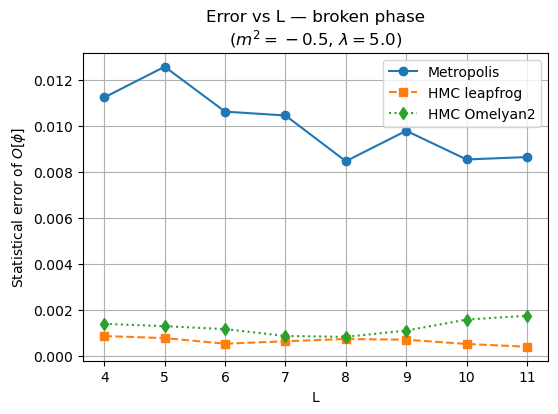

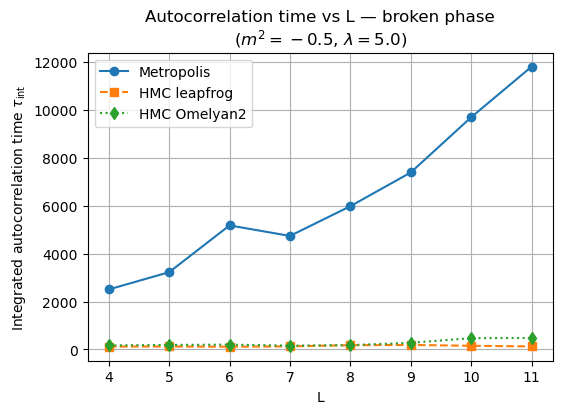

Applying binning:   0%|          | 0/160 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/160 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/160 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/160 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/160 [00:00<?, ?it/s]

...

Applying binning:   0%|          | 0/160 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/160 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/160 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/160 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/160 [00:00<?, ?it/s]

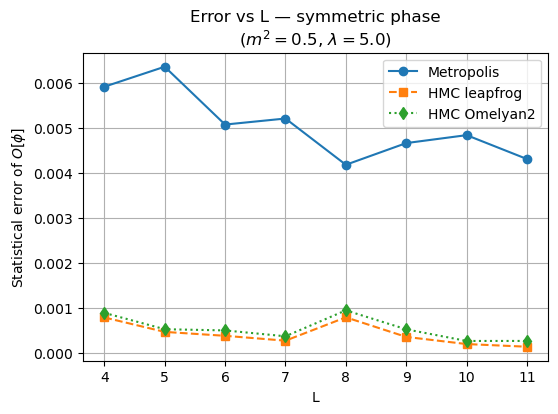

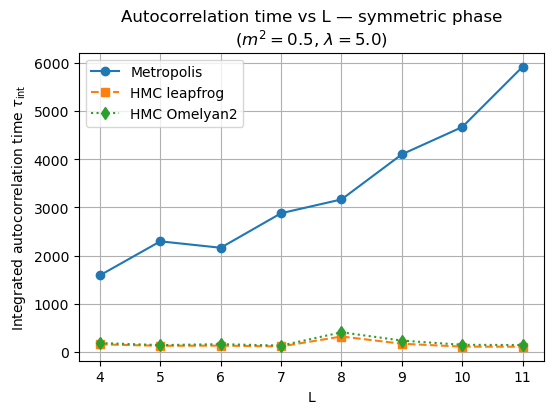

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from stats.analysis import apply_binning, integrated_autocorr_time, autocorrelation

L_vals = list(range(4, 12))

phases = {
    "broken": {"m2": -0.5, "lam": 5.0},
    "symmetric": {"m2": +0.5, "lam": 5.0},
}

algorithms = ["Metropolis", "HMC_leapfrog", "HMC_omelyan2"]

for phase_name, params in phases.items():
    m2 = params["m2"]
    lam = params["lam"]

    err = {alg: [] for alg in algorithms}
    tau = {alg: [] for alg in algorithms}

    for L in L_vals:
        data = np.load(
            f"observable_measurements_{phase_name}_"
            f"m2{m2}_lam{lam}_L{L}_all_algs.npz"
        )

        for alg in algorithms:
            series = data[f"{alg}_L{L}"]

            bins, errs = apply_binning(series)
            err[alg].append(errs[-1])

            tau[alg].append(
                integrated_autocorr_time(autocorrelation(series))
            )

    # --- Error plot ---
    plt.figure(figsize=(6, 4))
    plt.plot(L_vals, err["Metropolis"], "o-", label="Metropolis")
    plt.plot(L_vals, err["HMC_leapfrog"], "s--", label="HMC leapfrog")
    plt.plot(L_vals, err["HMC_omelyan2"], "d:", label="HMC Omelyan2")

    plt.xlabel("L")
    plt.ylabel("Statistical error of $O[\\phi]$")
    plt.title(
        f"Error vs L — {phase_name} phase\n"
        rf"($m^2={m2}$, $\lambda={lam}$)"
    )
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- Autocorrelation plot ---
    plt.figure(figsize=(6, 4))
    plt.plot(L_vals, tau["Metropolis"], "o-", label="Metropolis")
    plt.plot(L_vals, tau["HMC_leapfrog"], "s--", label="HMC leapfrog")
    plt.plot(L_vals, tau["HMC_omelyan2"], "d:", label="HMC Omelyan2")

    plt.xlabel("L")
    plt.ylabel(r"Integrated autocorrelation time $\tau_{\mathrm{int}}$")
    plt.title(
        f"Autocorrelation time vs L — {phase_name} phase\n"
        rf"($m^2={m2}$, $\lambda={lam}$)"
    )
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
phi_samples_pbc = []

sim_pbc = MetropolisSim(
    initial_phi,
    mass2=m2,
    lamb=lam,
    width=eps,
    rng=rng,
    bc=BoundaryCondition.PBC
)

for _ in range(N_measurements):
    sim_pbc.update()
    phi_samples_pbc.append(sim_pbc.phi.copy())

phi_samples_pbc = np.asarray(phi_samples_pbc)

phi_samples_apbc = []

sim_apbc = MetropolisSim(
    initial_phi,
    mass2=m2,
    lamb=lam,
    width=eps,
    rng=rng,
    bc=BoundaryCondition.APBC
)

for _ in range(N_measurements):
    sim_apbc.update()
    phi_samples_apbc.append(sim_apbc.phi.copy())

phi_samples_apbc = np.asarray(phi_samples_apbc)

Q_R = topological_charge_QR(
    phi_samples_pbc,
    phi_samples_apbc,
    spatial_axis=0
)

print("Q_R =", Q_R)


In [ ]:
# Compute Q_R for Metropolis
Q_R_met = topological_charge_QR(
    phi_samples_pbc=phi_samples_pbc_met,
    phi_samples_apbc=phi_samples_apbc_met,
    spatial_axis=0
)
print("Metropolis Q_R =", Q_R_met)

# Compute Q_R for HMC
Q_R_hmc = topological_charge_QR(
    phi_samples_pbc=phi_samples_pbc_hmc,
    phi_samples_apbc=phi_samples_apbc_hmc,
    spatial_axis=0
)
print("HMC Q_R =", Q_R_hmc)

# Metropolis time series
Q_R_series_met = Q_R_time_series(phi_samples_pbc_met, phi_samples_apbc_met)

# HMC time series
Q_R_series_hmc = Q_R_time_series(phi_samples_pbc_hmc, phi_samples_apbc_hmc)

acf_met = autocorrelation(Q_R_series_met)
acf_hmc = autocorrelation(Q_R_series_hmc)

tau_int_met = integrated_autocorr_time(acf_met)
tau_int_hmc = integrated_autocorr_time(acf_hmc)

print(f"Integrated autocorrelation time Metropolis: τ_int = {tau_int_met:.1f}")
print(f"Integrated autocorrelation time HMC: τ_int = {tau_int_hmc:.1f}")

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(Q_R_series_met, label="Metropolis")
plt.plot(Q_R_series_hmc, label="HMC")
plt.xlabel("Monte Carlo step")
plt.ylabel("$Q_R$ (topological charge)")
plt.title("Time series of $Q_R$")
plt.legend()
plt.grid(True)
plt.show()

# Optional: plot autocorrelation function
plt.figure(figsize=(10, 5))
plt.plot(acf_met, label="Metropolis")
plt.plot(acf_hmc, label="HMC")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation of $Q_R$")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Run Metropolis
phi_samples_pbc_met = run_metropolis(phi0_pbc, mass2, lamb, width, n_steps)
phi_samples_apbc_met = run_metropolis(phi0_apbc, mass2, lamb, width, n_steps)
Q_R_series_met = Q_R_time_series(phi_samples_pbc_met, phi_samples_apbc_met)

# Run HMC
phi_samples_pbc_hmc = run_hmc(phi0_pbc, mass2, lamb, width, n_steps, integrator=integrators.leapfrog)
phi_samples_apbc_hmc = run_hmc(phi0_apbc, mass2, lamb, width, n_steps, integrator=integrators.leapfrog)
Q_R_series_hmc = Q_R_time_series(phi_samples_pbc_hmc, phi_samples_apbc_hmc)


acf_met = autocorrelation(Q_R_series_met)
acf_hmc = autocorrelation(Q_R_series_hmc)

tau_int_met = integrated_autocorr_time(acf_met)
tau_int_hmc = integrated_autocorr_time(acf_hmc)

print(f"Integrated autocorrelation time τ_int(Q_R) Metropolis: {tau_int_met:.2f}")
print(f"Integrated autocorrelation time τ_int(Q_R) HMC: {tau_int_hmc:.2f}")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(Q_R_series_met, label="Metropolis", alpha=0.7)
plt.plot(Q_R_series_hmc, label="HMC", alpha=0.7)
plt.xlabel("Monte Carlo steps")
plt.ylabel("$Q_R$ (topological charge)")
plt.title("Time series of $Q_R$: Metropolis vs HMC")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(acf_met, label="Metropolis")
plt.plot(acf_hmc, label="HMC")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation of $Q_R$: Metropolis vs HMC")
plt.legend()
plt.grid(True)
plt.show()



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from algorithms.metropolis import run_metropolis
from algorithms.hmc import run_hmc
from physics.topology import Q_R_time_series
from utils.stats import autocorrelation, integrated_autocorr_time
from numpy.random import default_rng
import algorithms.integrators as integrators

# ------------------------------
# Simulation parameters
# ------------------------------
L = 10                       # lattice size
mass2 = -0.5                 # bare mass squared
lamb = 5.0                   # quartic coupling
n_steps = 20_000             # number of Monte Carlo steps
width = 0.5 / L              # Metropolis step size
rng = default_rng(seed=42)

# Initialize phi configurations for PBC and APBC
phi0_pbc = rng.random((L, L))
phi0_apbc = rng.random((L, L))

# ------------------------------
# Run Metropolis
# ------------------------------
phi_samples_pbc_met = run_metropolis(phi0_pbc, mass2, lamb, width, n_steps)
phi_samples_apbc_met = run_metropolis(phi0_apbc, mass2, lamb, width, n_steps)

# Compute topological charge time series
Q_R_series_met = Q_R_time_series(phi_samples_pbc_met, phi_samples_apbc_met)

# ------------------------------
# Run HMC (leapfrog)
# ------------------------------
phi_samples_pbc_hmc = run_hmc(phi0_pbc, mass2, lamb, width, n_steps, integrator=integrators.leapfrog)
phi_samples_apbc_hmc = run_hmc(phi0_apbc, mass2, lamb, width, n_steps, integrator=integrators.leapfrog)

# Compute topological charge time series
Q_R_series_hmc = Q_R_time_series(phi_samples_pbc_hmc, phi_samples_apbc_hmc)

# ------------------------------
# Autocorrelation analysis
# ------------------------------
acf_met = autocorrelation(Q_R_series_met)
acf_hmc = autocorrelation(Q_R_series_hmc)

tau_int_met = integrated_autocorr_time(acf_met)
tau_int_hmc = integrated_autocorr_time(acf_hmc)

print(f"Integrated autocorrelation time τ_int(Q_R) Metropolis: {tau_int_met:.2f}")
print(f"Integrated autocorrelation time τ_int(Q_R) HMC: {tau_int_hmc:.2f}")

# ------------------------------
# Plot Q_R time series
# ------------------------------
plt.figure(figsize=(12, 5))
plt.plot(Q_R_series_met, label="Metropolis", alpha=0.7)
plt.plot(Q_R_series_hmc, label="HMC (leapfrog)", alpha=0.7)
plt.xlabel("Monte Carlo steps")
plt.ylabel("$Q_R$ (topological charge)")
plt.title("Time series of $Q_R$: Metropolis vs HMC")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------
# Plot autocorrelation functions
# ------------------------------
plt.figure(figsize=(12, 5))
plt.plot(acf_met, label="Metropolis")
plt.plot(acf_hmc, label="HMC (leapfrog)")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation of $Q_R$: Metropolis vs HMC")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def reconstruct_kink_profile(phi_samples_apbc: np.ndarray, spatial_axis: int = 0) -> np.ndarray:
    """
    Reconstructs the kink profile from APBC configurations.
    
    Parameters
    ----------
    phi_samples_apbc : np.ndarray
        Monte Carlo samples with APBC, shape (n_samples, Lx, Ly)
    spatial_axis : int
        Axis corresponding to the spatial direction with APBC

    Returns
    -------
    phi_avg : np.ndarray
        Average field along the spatial axis (kink profile)
    """
    # Average over Monte Carlo samples
    phi_mean = np.mean(phi_samples_apbc, axis=0)
    
    # If 2D, average over transverse direction
    axes_to_average = tuple(i for i in range(phi_mean.ndim) if i != spatial_axis)
    phi_profile = np.mean(phi_mean, axis=axes_to_average)
    
    return phi_profile

# ------------------------------
# Example usage
# ------------------------------
# phi_samples_apbc: array of shape (n_samples, L, L)
phi_profile = reconstruct_kink_profile(phi_samples_apbc, spatial_axis=0)

# Plot kink profile
plt.figure(figsize=(8,5))
plt.plot(phi_profile, 'o-', label="Monte Carlo kink profile")
plt.xlabel("Spatial site")
plt.ylabel(r"$\phi(x)$")
plt.title("Reconstructed kink profile (APBC)")
plt.grid(True)
plt.legend()
plt.show()
